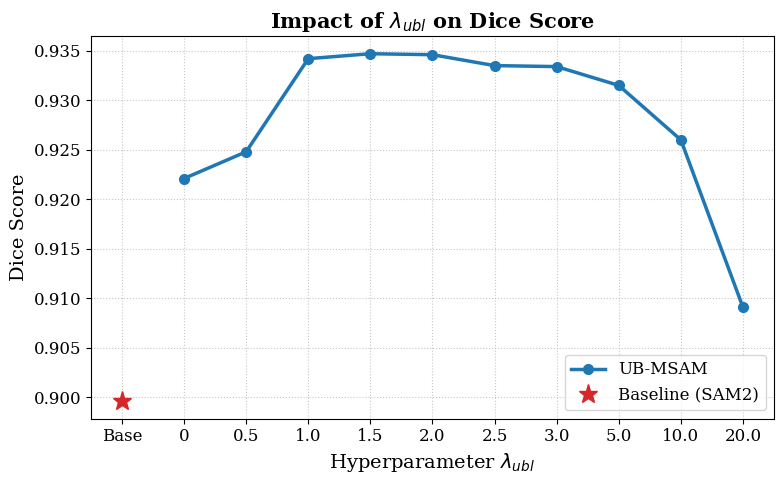

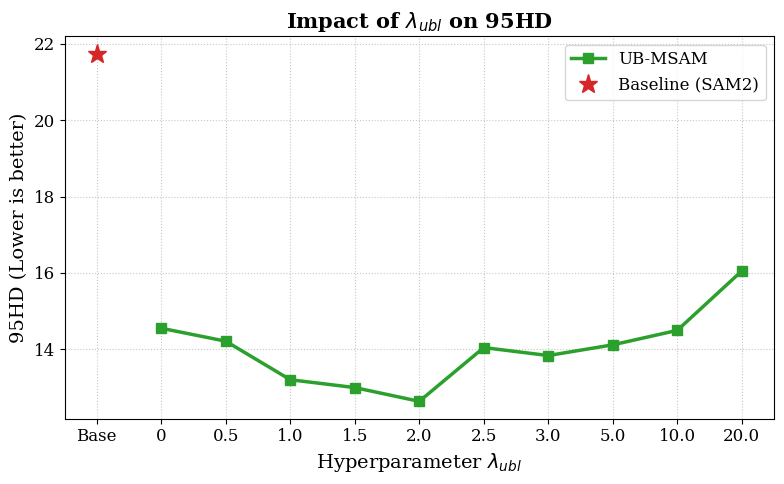

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 数据准备 ---
# 直接将 lambda 视为字符串标签，以保证等间距
lambdas_str = ['0', '0.5', '1.0', '1.5', '2.0', '2.5', '3.0', '5.0', '10.0', '20.0']
dice = [0.9221, 0.9248, 0.9342, 0.9347, 0.9346, 0.9335, 0.9334, 0.9315, 0.9260, 0.9091]
hd95 = [14.5528, 14.2134, 13.2045, 12.9993, 12.6389, 14.0464, 13.8381, 14.1183, 14.4969, 16.0519]
baseline_dice = 0.8996
baseline_hd95 = 21.7398

# --- 2. 坐标轴等间距处理逻辑 ---
# 总共 11 个点：1个 Baseline + 10个实验组点
# 生成 [0, 1, 2, 3, ..., 10] 作为等间距的实际绘图 X 坐标
x_positions = np.arange(len(lambdas_str) + 1)  
x_labels = ['Base'] + lambdas_str  # 拼接完整的 X 轴标签

# Baseline 绘制在 x=0 的位置
x_base = x_positions[0]
# 折线图绘制在 x=1 到 x=10 的位置
x_line = x_positions[1:]

# --- 3. 全局绘图设置 ---
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# ==========================================
# 4. 绘制 Dice 的单独折线图
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 5))

# 使用等间距的 x_line 来画折线
ax1.plot(x_line, dice, marker='o', markersize=7, linestyle='-', color='#1f77b4', linewidth=2.5, label='UB-MSAM')
# 在 x=0 的位置画 Baseline (单独红星)
ax1.plot([x_base], [baseline_dice], marker='*', markersize=14, color='#d62728', linestyle='None', label='Baseline (SAM2)')

# 设置等间距的 X 轴刻度和替换文本
ax1.set_xticks(x_positions)
ax1.set_xticklabels(x_labels) 
ax1.set_xlim(-0.5, len(x_positions) - 0.5) # 左右各留出 0.5 的边距，让点不贴边

ax1.set_xlabel(r'Hyperparameter $\lambda_{ubl}$', fontsize=14)
ax1.set_ylabel('Dice Score', fontsize=14)
ax1.set_title('Impact of $\lambda_{ubl}$ on Dice Score', fontsize=15, fontweight='bold')

ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend(loc='lower right')

plt.tight_layout()
fig1.savefig('dice_sensitivity_uniform.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig1)

# ==========================================
# 5. 绘制 HD95 的单独折线图
# ==========================================
fig2, ax2 = plt.subplots(figsize=(8, 5))

# 使用等间距的 x_line 来画折线
ax2.plot(x_line, hd95, marker='s', markersize=7, linestyle='-', color='#2ca02c', linewidth=2.5, label='UB-MSAM')
# 在 x=0 的位置画 Baseline
ax2.plot([x_base], [baseline_hd95], marker='*', markersize=14, color='#d62728', linestyle='None', label='Baseline (SAM2)')

# 设置等间距的 X 轴刻度和替换文本
ax2.set_xticks(x_positions)
ax2.set_xticklabels(x_labels)
ax2.set_xlim(-0.5, len(x_positions) - 0.5)

ax2.set_xlabel(r'Hyperparameter $\lambda_{ubl}$', fontsize=14)
ax2.set_ylabel('95HD (Lower is better)', fontsize=14)
ax2.set_title('Impact of $\lambda_{ubl}$ on 95HD', fontsize=15, fontweight='bold')

ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
fig2.savefig('hd95_sensitivity_uniform.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig2)